In [1]:
!pip3 install -r requirements.txt



Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import sklearn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


cuda


## Data Pipeline

In [3]:
df = pd.read_csv("GALAXY_DATASET/final_15000.csv")
df.head()

,dr7objid,asset_id,t01_smooth_or_features_a01_smooth_debiased,t01_smooth_or_features_a02_features_or_disk_debiased,t02_edgeon_a04_yes_debiased,t03_bar_a06_bar_debiased,t04_spiral_a08_spiral_debiased,t08_odd_feature_a24_merger_debiased,t08_odd_feature_a22_irregular_debiased
0,587722981742018657,15,0.003,0.955,0.000000,0.000000,0.733360,0.003648,0.526693
1,587722981744050315,35,0.000,0.981,0.000289,0.402361,0.998695,0.000000,0.045512
2,587722981746016481,63,0.020,0.973,0.000000,0.216366,0.995563,0.000000,0.437910
3,587722981747654761,81,0.766,0.757,0.108623,0.381713,0.926622,0.000000,0.889990
4,587722981747982465,89,0.154,0.846,0.003660,0.885386,0.839584,0.211087,0.340519


In [4]:
img_folder = "GALAXY_DATASET/Images Differing sizes/224"

# 10 images are missing from the folder, drop those rows
valid = set(int(f.replace(".jpg", "")) for f in os.listdir(img_folder) if f.endswith(".jpg"))
df = df[df["asset_id"].isin(valid)].reset_index(drop=True)
print(len(df))  # should be 14990

4048


In [5]:
def make_label(row, thresh=0.6):

    smooth    = row["t01_smooth_or_features_a01_smooth_debiased"]
    featured  = row["t01_smooth_or_features_a02_features_or_disk_debiased"]

    irregular=row["t08_odd_feature_a22_irregular_debiased"]
    bar       = row["t03_bar_a06_bar_debiased"]
    spiral    = row["t04_spiral_a08_spiral_debiased"]
    edgeon    = row["t02_edgeon_a04_yes_debiased"]
    merger = row["t08_odd_feature_a24_merger_debiased"]
   

    if merger>thresh:
        return "merger"
    elif edgeon>thresh:
        return "edge_on"
    elif irregular>thresh:
        return "irregular"
    elif bar>thresh:
        return "barred_spiral"
    elif spiral>thresh:
        return "spiral"
    elif smooth>thresh:
        return "smooth"
    else:
        return "featured"
    

df["label"] = df.apply(make_label, axis=1)
df = df.dropna(subset=["label"]).reset_index(drop=True)
print(df["label"].value_counts())

label
spiral           1260
smooth            964
barred_spiral     702
featured          521
edge_on           365
irregular         165
merger             71
Name: count, dtype: int64


In [6]:
classes = sorted(df["label"].dropna().unique())

print(classes)
print(f"Number of classes: {len(classes)}")

class_to_idx = {c:i for i, c in enumerate(classes)}
idx_to_class = {i:c for c, i in class_to_idx.items()}

['barred_spiral', 'edge_on', 'featured', 'irregular', 'merger', 'smooth', 'spiral']
Number of classes: 7


In [7]:
class GalaxyDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        path = os.path.join(self.img_dir, f"{int(row['asset_id'])}.jpg")
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, int(row["label_idx"])

In [8]:
# Remove classes with fewer than 200 samples
label_counts = df["label"].value_counts()
df = df[df["label"].isin(label_counts[label_counts >= 50].index)].reset_index(drop=True)
print(df["label"].value_counts())

# Create numeric label column
label_classes = sorted(df["label"].unique())
label_to_idx = {label: idx for idx, label in enumerate(label_classes)}
df["label_idx"] = df["label"].map(label_to_idx)

print(f"Number of classes: {len(label_classes)}")
print(label_to_idx)

#made with claude shouldn't use^^^^^ figure out issues
#####################################################

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["label"])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

##

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label_idx"]),
    y=train_df["label_idx"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
).to(device)

##


print("Class Weights:", class_weights)

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_loader = DataLoader(GalaxyDataset(train_df, img_folder, train_tfms), batch_size=32, shuffle=True,  num_workers=1)
val_loader   = DataLoader(GalaxyDataset(val_df,   img_folder, val_tfms),   batch_size=32, shuffle=False, num_workers=1)
test_loader  = DataLoader(GalaxyDataset(test_df,  img_folder, val_tfms),   batch_size=32, shuffle=False, num_workers=1)

print(f"train: {len(train_loader.dataset)}  val: {len(val_loader.dataset)}  test: {len(test_loader.dataset)}")

label
spiral           1260
smooth            964
barred_spiral     702
featured          521
edge_on           365
irregular         165
merger             71
Name: count, dtype: int64
Number of classes: 7
{'barred_spiral': 0, 'edge_on': 1, 'featured': 2, 'irregular': 3, 'merger': 4, 'smooth': 5, 'spiral': 6}
Class Weights: tensor([0.8243, 1.5871, 1.1088, 3.5193, 8.0943, 0.5996, 0.4589],
       device='cuda:0')
train: 2833  val: 607  test: 608


## Model

In [9]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# freeze everything
for param in model.parameters():
    param.requires_grad = False

# swap the head for 4 classes
model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(device)

## Training

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct = 0.0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            loss = criterion(out, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(imgs)
            correct += (out.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n

### Phase 1 — train head only (backbone frozen)

In [11]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

EPOCHS_P1 = 3
best_val_acc = 0.0
patience = 5
counter = 0

for epoch in range(EPOCHS_P1):
    tl, ta = run_epoch(model, train_loader, criterion, optimizer)
    vl, va = run_epoch(model, val_loader,   criterion)

    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)

    if va > best_val_acc:
        best_val_acc = va
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter +=1

    print(f"epoch {epoch+1}/{EPOCHS_P1}  train_loss={tl:.4f}  val_loss={vl:.4f}  train_acc={ta:.4f}  val_acc={va:.4f}")

    if counter >= patience:
        print("Early stopping triggered")
        break

/home/rnelson3/.local/lib/python3.12/site-packages/torch/nn/modules/conv.py:456: UserWarning: Attempt to open cnn_infer failed: handle=0 error: libcudnn_cnn_infer.so.8: cannot open shared object file: No such file or directory (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:78.)
  return F.conv2d(input, weight, bias, self.stride,


epoch 1/3  train_loss=1.9521  val_loss=1.8785  train_acc=0.2150  val_acc=0.2306
epoch 2/3  train_loss=1.8203  val_loss=1.8199  train_acc=0.2736  val_acc=0.2142
epoch 3/3  train_loss=1.7624  val_loss=1.8081  train_acc=0.2997  val_acc=0.3657


### Phase 2 — unfreeze everything and fine-tune

In [12]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": model.fc.parameters(),  "lr": 1e-3},
    {"params": [p for name, p in model.named_parameters() if "fc" not in name], "lr": 1e-4}
])

EPOCHS_P2 = 20
counter = 0

for epoch in range(EPOCHS_P2):
    tl, ta = run_epoch(model, train_loader, criterion, optimizer)
    vl, va = run_epoch(model, val_loader,   criterion)

    history["train_loss"].append(tl)
    history["val_loss"].append(vl)
    history["train_acc"].append(ta)
    history["val_acc"].append(va)

    if va > best_val_acc:
        best_val_acc = va
        counter=0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter +=1

    print(f"epoch {EPOCHS_P1+epoch+1}/{EPOCHS_P1+EPOCHS_P2}  train_loss={tl:.4f}  val_loss={vl:.4f}  train_acc={ta:.4f}  val_acc={va:.4f}")

    if counter >= patience:
        print("Early stopping triggered")
        break

print(f"\nbest val acc: {best_val_acc:.4f}")

epoch 4/23  train_loss=1.7546  val_loss=1.5776  train_acc=0.3233  val_acc=0.4102
epoch 5/23  train_loss=1.5685  val_loss=1.6433  train_acc=0.3791  val_acc=0.3130
epoch 6/23  train_loss=1.4882  val_loss=1.5607  train_acc=0.3879  val_acc=0.3921
epoch 7/23  train_loss=1.4163  val_loss=1.6453  train_acc=0.4169  val_acc=0.3822
epoch 8/23  train_loss=1.3355  val_loss=1.6774  train_acc=0.4299  val_acc=0.4316
epoch 9/23  train_loss=1.3191  val_loss=1.7063  train_acc=0.4490  val_acc=0.2883
epoch 10/23  train_loss=1.2948  val_loss=1.7420  train_acc=0.4455  val_acc=0.3740
epoch 11/23  train_loss=1.2671  val_loss=1.7157  train_acc=0.4681  val_acc=0.3509
epoch 12/23  train_loss=1.1964  val_loss=1.5396  train_acc=0.4906  val_acc=0.3822
epoch 13/23  train_loss=1.1080  val_loss=1.8074  train_acc=0.5143  val_acc=0.4481
epoch 14/23  train_loss=1.1108  val_loss=1.8047  train_acc=0.5058  val_acc=0.3904
epoch 15/23  train_loss=1.0222  val_loss=1.8126  train_acc=0.5535  val_acc=0.4580
epoch 16/23  train_los

## Results

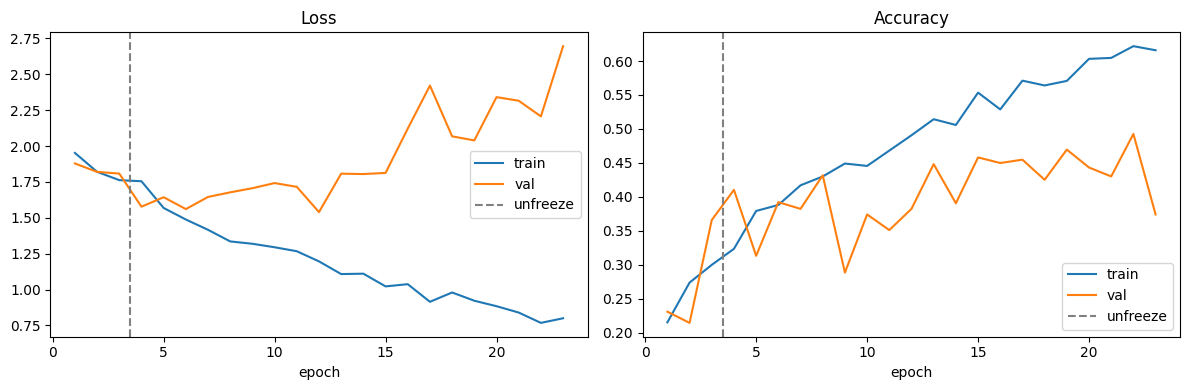

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs, history["train_loss"], label="train")
ax1.plot(epochs, history["val_loss"],   label="val")
ax1.axvline(EPOCHS_P1 + 0.5, color="gray", linestyle="--", label="unfreeze")
ax1.set_title("Loss")
ax1.set_xlabel("epoch")
ax1.legend()

ax2.plot(epochs, history["train_acc"], label="train")
ax2.plot(epochs, history["val_acc"],   label="val")
ax2.axvline(EPOCHS_P1 + 0.5, color="gray", linestyle="--", label="unfreeze")
ax2.set_title("Accuracy")
ax2.set_xlabel("epoch")
ax2.legend()

plt.tight_layout()
plt.show()

test accuracy: 0.5132


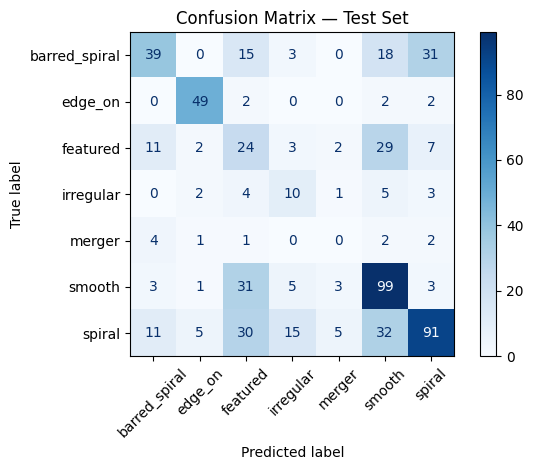

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())
        
test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"test accuracy: {test_acc:.4f}")
present_classes = [classes[i] for i in sorted(set(all_labels) | set(all_preds))]

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=present_classes)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()